In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
import pandas as pd
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
from math import lgamma, log, exp, comb
from SolverFunction import _find_unknown,auto_bracket,solve_quantity
import matplotlib.animation as animation
quantity_support()
%matplotlib widget
import sympy as sp
from sympy.solvers import solve
from sympy import symbols, Eq, Function, diff, integrate, simplify, expand, factor


In [2]:
def snells_law(n1,n2,theta1,theta2):
    return n1 * np.sin(theta1) - n2 * np.sin(theta2)

solve_quantity(snells_law, theta2=None, n1=1.0, n2=1.5, theta1=30*u.degree, bracket=(0, 90)*u.degree)

def optical_depth(true_depth, n, theta, optical_depth):
    return true_depth / (n * np.cos(theta)) - optical_depth

solve_quantity(optical_depth, true_depth=1*u.km, n=1.47, theta=0*u.degree, optical_depth=None, bracket=(0, 100)*u.km)

def critical_angle(n1, n2, critical_angle):
    return n1 * np.sin(critical_angle) - n2

solve_quantity(critical_angle, n1=2.42, n2=1.0, critical_angle=None, bracket=(0, 90)*u.degree)

def reflectance(n1, n2, incident_angle, reflectance):
    transmitted_angle = np.arcsin(n1 * np.sin(incident_angle) / n2)
    r_parallel = (n2 * np.cos(incident_angle) - n1 * np.cos(transmitted_angle)) / (n2 * np.cos(incident_angle) + n1 * np.cos(transmitted_angle))
    r_perpendicular = (n1 * np.cos(incident_angle) - n2 * np.cos(transmitted_angle)) / (n1 * np.cos(incident_angle) + n2 * np.cos(transmitted_angle))
    return 0.5 * (r_parallel**2 + r_perpendicular**2) - reflectance

solve_quantity(reflectance, n1=1.0, n2=1.5, incident_angle=65*u.degree, reflectance=None, bracket=(0, 1)*u.dimensionless_unscaled)

def brewster_angle(n1, n2, brewster_angle):
    return np.tan(brewster_angle) - n2 / n1

solve_quantity(brewster_angle, n1=1.33, n2=1, brewster_angle=None, bracket=(0, 90)*u.degree)

<Quantity 36.93876273 deg>

In [3]:
# Question 1, come back to this later.

# define a function to calculate the amplitude of the evanescent wave at a distance z from the interface
# use astropy units for the incident angle and the distance z
def evanescent_wave_amplitude(lambda_vacuum,n1, n2, incident_angle, z, amplitude):
    # calculate the critical angle for total internal reflection
    critical_angle = np.arcsin(n2 / n1)
    print(critical_angle)
    # check if the incident angle is greater than the critical angle
    if incident_angle.value > critical_angle:
        # calculate the decay constant for the evanescent wave
        delta = lambda_vacuum / (2 * np.pi * np.sqrt(n1**2 * np.sin(incident_angle)**2 - n2**2))
        print(delta)
        # calculate the amplitude of the evanescent wave at distance z
        return np.exp(-z/delta) - amplitude
    else:
        raise ValueError("Incident angle must be greater than the critical angle for total internal reflection.")

solve_quantity(evanescent_wave_amplitude, lambda_vacuum=500*u.nm, n1=1.5, n2=1.0, incident_angle=45*u.degree, z=None, amplitude=1/np.e*u.dimensionless_unscaled, bracket=(0, 800)*u.nm)
#solve_quantity(evanescent_wave_amplitude, n1=1.5, n2=1.0, incident_angle=45*u.degree, z=None, amplitude=1*u.dimensionless_unscaled, bracket=(0, 800)*u.nm)

0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm
0.7297276562269663
225.0790790392767 nm


<Quantity 225.07907904 nm>

Approximate polarization angle (minimum R_parallel): 75.25 deg


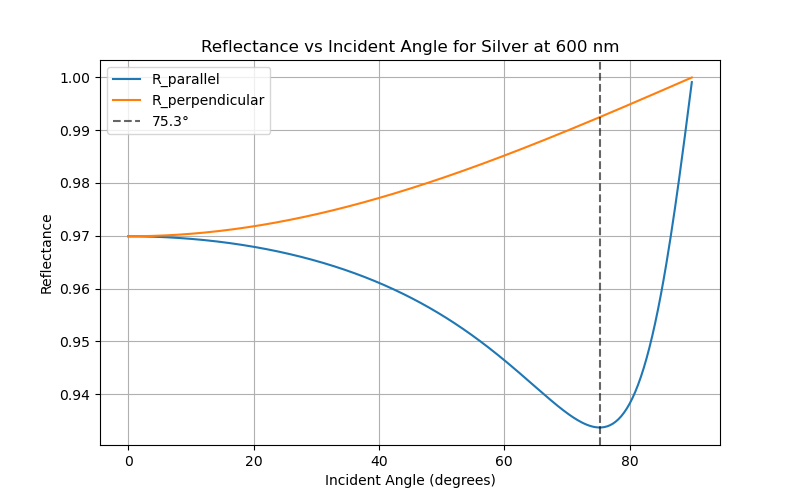

In [4]:
def reflectance_silver(n, k, incident_angle_deg):
    N = n + 1j * k
    theta_i = np.deg2rad(incident_angle_deg)

    sin_theta_i = np.sin(theta_i)
    cos_theta_i = np.cos(theta_i)

    sin_theta_t = sin_theta_i / N
    cos_theta_t = np.sqrt(1 - sin_theta_t**2)

    r_perpendicular = (cos_theta_i - N * cos_theta_t) / (cos_theta_i + N * cos_theta_t)
    r_parallel = (N * cos_theta_i - cos_theta_t) / (N * cos_theta_i + cos_theta_t)

    R_perpendicular = np.abs(r_perpendicular) ** 2
    R_parallel = np.abs(r_parallel) ** 2
    return R_parallel, R_perpendicular


incident_angles = np.linspace(0, 89.9, 400)
R_parallel = []
R_perpendicular = []

for angle in incident_angles:
    rp, rs = reflectance_silver(0.13, 4.0, angle)
    R_parallel.append(rp)
    R_perpendicular.append(rs)

R_parallel = np.array(R_parallel)
R_perpendicular = np.array(R_perpendicular)

polarization_angle = incident_angles[np.argmin(R_parallel)]
print(f"Approximate polarization angle (minimum R_parallel): {polarization_angle:.2f} deg")

plt.figure(figsize=(8, 5))
plt.plot(incident_angles, R_parallel, label='R_parallel')
plt.plot(incident_angles, R_perpendicular, label='R_perpendicular')
plt.axvline(polarization_angle, color='k', linestyle='--', alpha=0.6, label=f'{polarization_angle:.1f}°')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Reflectance')
plt.title('Reflectance vs Incident Angle for Silver at 600 nm')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
def magnification(object_distance, image_distance, magnification):
    return -image_distance / object_distance - magnification
solve_quantity(magnification, object_distance=150*u.mm, image_distance=300*u.mm, magnification=None, bracket=(-100,100)*u.dimensionless_unscaled)

def lens(focal_length, object_distance, image_distance):
    return 1/focal_length - 1/object_distance - 1/image_distance
solve_quantity(lens, focal_length=-75*u.mm, object_distance=-50*u.mm, image_distance=None, bracket=(1, 300)*u.mm)

# Ray trace for a mirror, object distance 3 cm, focal length 6 cm. Find image distance
def mirror_equation(object_distance, image_distance, focal_length):
    return 1/object_distance + 1/image_distance - 1/focal_length
solve_quantity(mirror_equation, object_distance=3*u.cm, image_distance=None, focal_length=6*u.cm, bracket=(-100, -0.1)*u.cm)


ValueError: f(a) and f(b) must have different signs

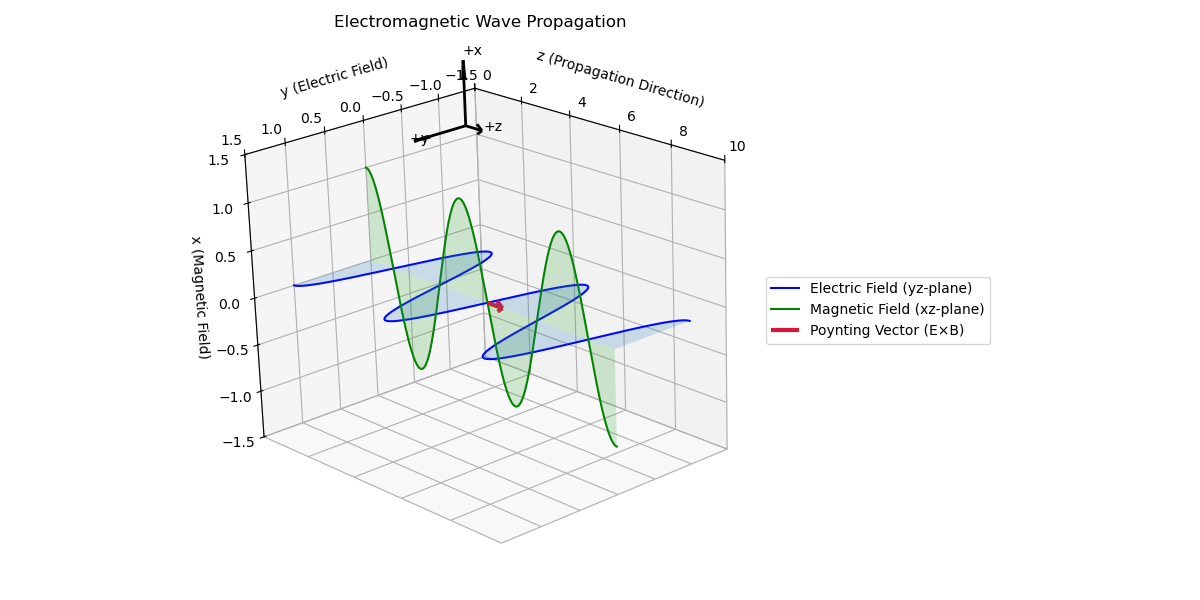

In [65]:

# Animate EM waves with E in the yz-plane and B in the xz-plane
try:
    ani.event_source.stop()
except Exception:
    pass

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

t_values = np.linspace(0, 2*np.pi, 400)
z_values = np.linspace(0, 10, 400)
E0 = 1
B0 = 1
k = 0.5*np.pi
omega = 2*np.pi

E_values = np.array([[electric_wave(E0, k, omega, t, z) for z in z_values] for t in t_values])
B_values = np.array([[magnetic_wave(B0, k, omega, t, z) for z in z_values] for t in t_values])

# Electric field: yz-plane -> x = 0
line_E, = ax.plot(
    np.zeros_like(z_values),
    E_values[0],
    z_values,
    label='Electric Field (yz-plane)',
    c='blue'
)

# Magnetic field: xz-plane -> y = 0
line_B, = ax.plot(
    B_values[0],
    np.zeros_like(z_values),
    z_values,
    label='Magnetic Field (xz-plane)',
    c = 'g'
)

# Shaded area under Electric field in yz-plane
X_E = np.zeros((2, len(z_values)))
Y_E = np.vstack([np.zeros_like(z_values), E_values[0]])
Z_E = np.vstack([z_values, z_values])
surf_E = ax.plot_surface(
    X_E, Y_E, Z_E, color='tab:blue', alpha=0.20, linewidth=0, shade=False
)

# Shaded area under Magnetic field in xz-plane
X_B = np.vstack([np.zeros_like(z_values), B_values[0]])
Y_B = np.zeros((2, len(z_values)))
Z_B = np.vstack([z_values, z_values])
surf_B = ax.plot_surface(
    X_B, Y_B, Z_B, color='tab:green', alpha=0.20, linewidth=0, shade=False
)

# Poynting vector S = E x B points in +z direction
probe_idx = len(z_values) // 2
z_probe = z_values[probe_idx]
S_mag0 = E_values[0, probe_idx] * B_values[0, probe_idx]
poynting_len0 = 0.6 + 1.4 * abs(S_mag0)
poynting_arrow = ax.quiver(
    0, 0, z_probe,
    0, 0, poynting_len0,
    color='crimson',
    linewidth=3,
    arrow_length_ratio=0.35,
    label='Poynting Vector (E×B)'
)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(0, 10)
ax.set_xlabel('x (Magnetic Field)')
ax.set_ylabel('y (Electric Field)')
ax.set_zlabel('z (Propagation Direction)')
ax.set_title('Electromagnetic Wave Propagation')

# Static axis triad for orientation reference (moved to a less crowded corner)
axis_len = 0.7
triad_x0, triad_y0, triad_z0 = 1.2, -1.2, 0.5
ax.quiver(triad_x0, triad_y0, triad_z0, axis_len, 0, 0, color='k', linewidth=2)
ax.quiver(triad_x0, triad_y0, triad_z0, 0, axis_len, 0, color='k', linewidth=2)
ax.quiver(triad_x0, triad_y0, triad_z0, 0, 0, axis_len, color='k', linewidth=2)
ax.text(triad_x0 + axis_len + 0.06, triad_y0, triad_z0, '+x', color='k')
ax.text(triad_x0, triad_y0 + axis_len + 0.06, triad_z0, '+y', color='k')
ax.text(triad_x0, triad_y0, triad_z0 + axis_len + 0.06, '+z', color='k')

# Keep legend outside the plotting grid
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

# Corner-forward view with z tilted toward screen/left
ax.view_init(elev=45, azim=60, roll=-110)
ax.set_box_aspect((1, 1, 1.2))

def update(frame):
    global poynting_arrow, surf_E, surf_B
    frame = frame % len(t_values)

    line_E.set_data(np.zeros_like(z_values), E_values[frame])
    line_E.set_3d_properties(z_values)

    line_B.set_data(B_values[frame], np.zeros_like(z_values))
    line_B.set_3d_properties(z_values)

    surf_E.remove()
    surf_B.remove()

    Y_E_frame = np.vstack([np.zeros_like(z_values), E_values[frame]])
    surf_E = ax.plot_surface(
        X_E, Y_E_frame, Z_E, color='tab:blue', alpha=0.20, linewidth=0, shade=False
    )

    X_B_frame = np.vstack([np.zeros_like(z_values), B_values[frame]])
    surf_B = ax.plot_surface(
        X_B_frame, Y_B, Z_B, color='tab:green', alpha=0.20, linewidth=0, shade=False
    )

    S_mag = E_values[frame, probe_idx] * B_values[frame, probe_idx]
    poynting_len = 0.6 + 1.4 * abs(S_mag)

    poynting_arrow.remove()
    poynting_arrow = ax.quiver(
        0, 0, z_probe,
        0, 0, poynting_len,
        color='crimson',
        linewidth=3,
        arrow_length_ratio=0.35
    )

    return line_E, line_B, surf_E, surf_B, poynting_arrow

ani = animation.FuncAnimation(
    fig, update, frames=len(t_values), interval=17, blit=False
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()